# Part 4: Machine Learning Classification & Model Comparison

## 1. Project Overview
In this final stage, we build and evaluate several classification models to predict a YouTube channel's subscriber category based on the features engineered in the previous steps. We compare ***SVC, Random Forest, K-Nearest Neighbors, and Logistic Regression*** to identify the most accurate predictor.

### 1.1. Library Imports and Environment Setup
We import Scikit-Learn for modeling, StandardScaler for normalization, and visualization libraries like Seaborn to plot confusion matrices.

In [42]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


## 2. Data Preparation

### 2.1. Feature Scaling and Train/Test Split

We split the dataset into training (80%) and testing (20%) sets, applying StandardScaler to ensure all features contribute equally to the models.

In [43]:
# Load the ML-ready dataset
df = pd.read_csv("ML_data.csv")
df['class'] = df['class'].astype(int)

# Separate features (X) and target (y)
y = df['class'].to_numpy()
X = df.drop(['class'], axis=1)

# Split and Scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scale = preprocessing.StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)


### 2.2. Visualization Helper Function
This function allows us to visualize the performance of each model through a Confusion Matrix.

In [44]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

labels = [0, 1, 2, 3, 4, 5]
models_results = []

## 3. Model Training and Evaluation

### 3.1. Support Vector Classification (SVC)
Using an RBF kernel with optimized hyperparameters (C=100, gamma=0.001).

CV Score Mean: 0.7656
Test Accuracy: 0.7806


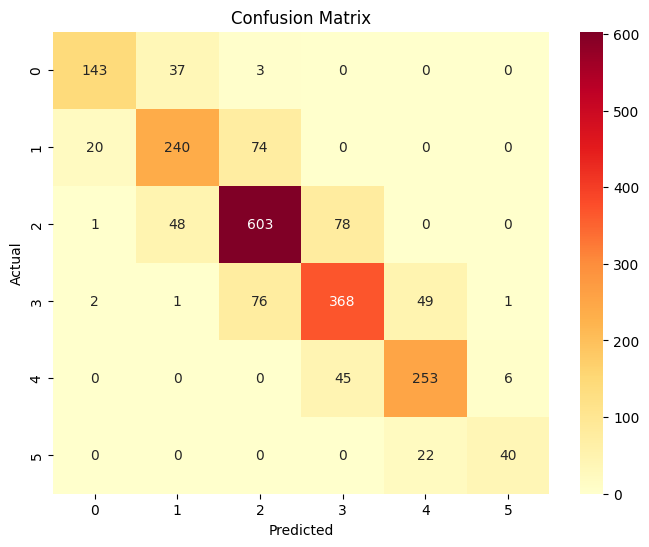

In [45]:
best_svc = SVC(C=100, gamma=0.001, kernel='rbf', probability=True)
best_svc.fit(X_train_scaled, y_train)

y_pred = best_svc.predict(X_test_scaled)
cv_scores = cross_val_score(best_svc, X_train_scaled, y_train, cv=5)
accuracy = accuracy_score(y_test, y_pred)

print(f"CV Score Mean: {cv_scores.mean():.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, labels=labels)
models_results.append({"model":"SVC", "SCORE":cv_scores.mean(), "ACCURACY":accuracy})

### 3.2. Random Forest Classifier
Evaluating an ensemble approach with 100 estimators.

CV Score: 0.7636312110732476
Test Accuracy: 0.7872037914691943


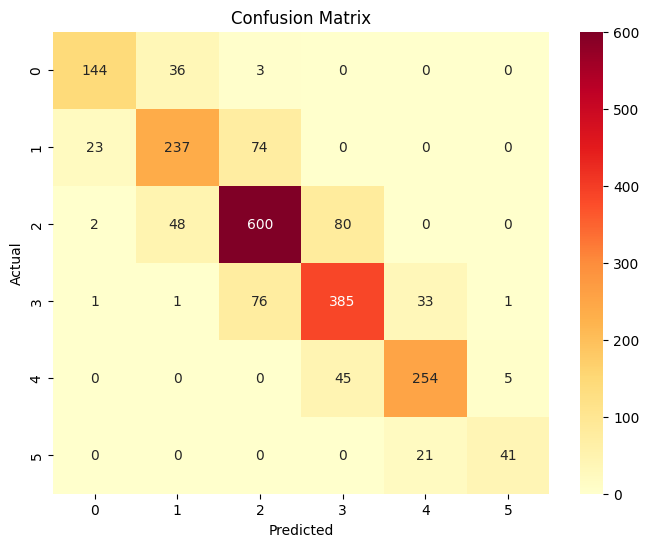

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       183
           1       0.74      0.71      0.72       334
           2       0.80      0.82      0.81       730
           3       0.75      0.77      0.76       497
           4       0.82      0.84      0.83       304
           5       0.87      0.66      0.75        62

    accuracy                           0.79      2110
   macro avg       0.81      0.76      0.78      2110
weighted avg       0.79      0.79      0.79      2110



In [46]:
rf_params = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, 
                                   max_depth=20, min_samples_leaf=2, max_features="log2")
rf_params.fit(X_train_scaled, y_train)

scores = cross_val_score(rf_params, X_train_scaled, y_train, cv=5)
y_pred = rf_params.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("CV Score:", scores.mean())
print("Test Accuracy:", accuracy)
plot_confusion_matrix(y_test, y_pred, labels=labels)
print(classification_report(y_test, y_pred))
models_results.append({"model":"RandomForestClassifier", "SCORE":scores.mean(), "ACCURACY":accuracy})

### 3.3. K-Nearest Neighbors (KNN)
We evaluate the KNN algorithm using 14 neighbors and Manhattan distance (p=1).

CV score: 0.7184673991521449
Accuracy score: 0.7393364928909952


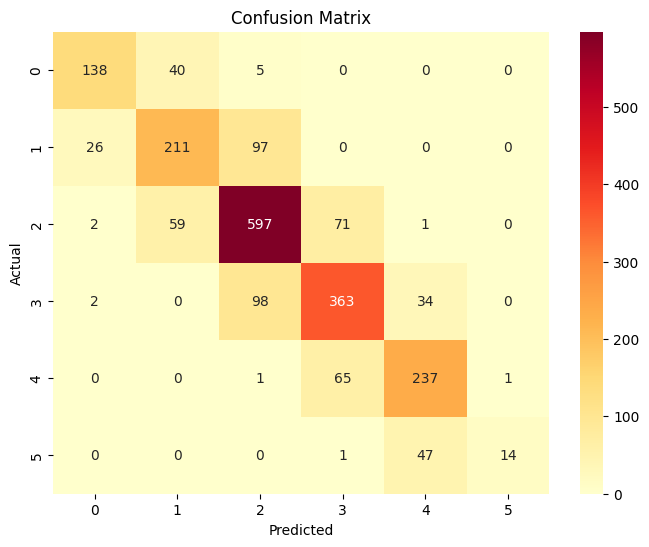

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       183
           1       0.68      0.63      0.66       334
           2       0.75      0.82      0.78       730
           3       0.73      0.73      0.73       497
           4       0.74      0.78      0.76       304
           5       0.93      0.23      0.36        62

    accuracy                           0.74      2110
   macro avg       0.78      0.66      0.68      2110
weighted avg       0.74      0.74      0.73      2110



In [47]:
# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=14, p=1, algorithm='auto')
knn_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
y_pred = knn_model.predict(X_test_scaled)
scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)
accuracy = accuracy_score(y_test, y_pred)

print("CV score:", scores.mean())
print("Accuracy score:", accuracy)
plot_confusion_matrix(y_test, y_pred, labels=labels)
print(classification_report(y_test, y_pred))

# Save results for comparison
models_results.append({"model": "KNeighborsClassifier", "SCORE": scores.mean(), "ACCURACY": accuracy})

### 3.4. Logistic Regression
A baseline linear model to compare against more complex non-linear algorithms.

CV score: 0.7593636310003736
Accuracy score: 0.7734597156398104


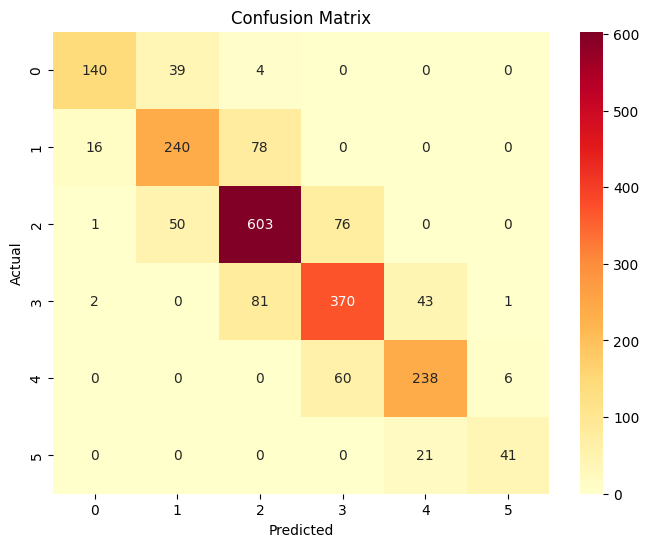

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       183
           1       0.73      0.72      0.72       334
           2       0.79      0.83      0.81       730
           3       0.73      0.74      0.74       497
           4       0.79      0.78      0.79       304
           5       0.85      0.66      0.75        62

    accuracy                           0.77      2110
   macro avg       0.80      0.75      0.77      2110
weighted avg       0.78      0.77      0.77      2110



In [48]:
# Initialize and train Logistic Regression
lgr = LogisticRegression()
lgr.fit(X_train_scaled, y_train)

# Predictions and Evaluation
y_pred = lgr.predict(X_test_scaled)
scores = cross_val_score(lgr, X_train_scaled, y_train, cv=5)
accuracy = accuracy_score(y_test, y_pred)

print("CV score:", scores.mean())
print("Accuracy score:", accuracy)
plot_confusion_matrix(y_test, y_pred, labels=labels)
print(classification_report(y_test, y_pred))

# Save results for comparison
models_results.append({"model": "LogisticRegression", "SCORE": scores.mean(), "ACCURACY": accuracy})

## 4. Performance Tracking & Model Comparison
# 4.1. Logging Results to CSV

To keep track of multiple experiments, we append the results of this session to a persistent CSV file.

In [49]:
import os

# Convert the results list to a DataFrame
new_df = pd.DataFrame(models_results)
file_path = 'models_statistics.csv'

# Check if file exists to handle the header correctly
if not os.path.isfile(file_path):
    new_df.to_csv(file_path, index=False)
else:
    new_df.to_csv(file_path, mode='a', index=False, header=False)
    print(f"📈 New results added to {file_path}!")

📈 New results added to models_statistics.csv!


## 4.2. Comparative Visualization

This final chart compares the Cross-Validation Score and the Test Accuracy across all models to identify the best performer and check for overfitting.

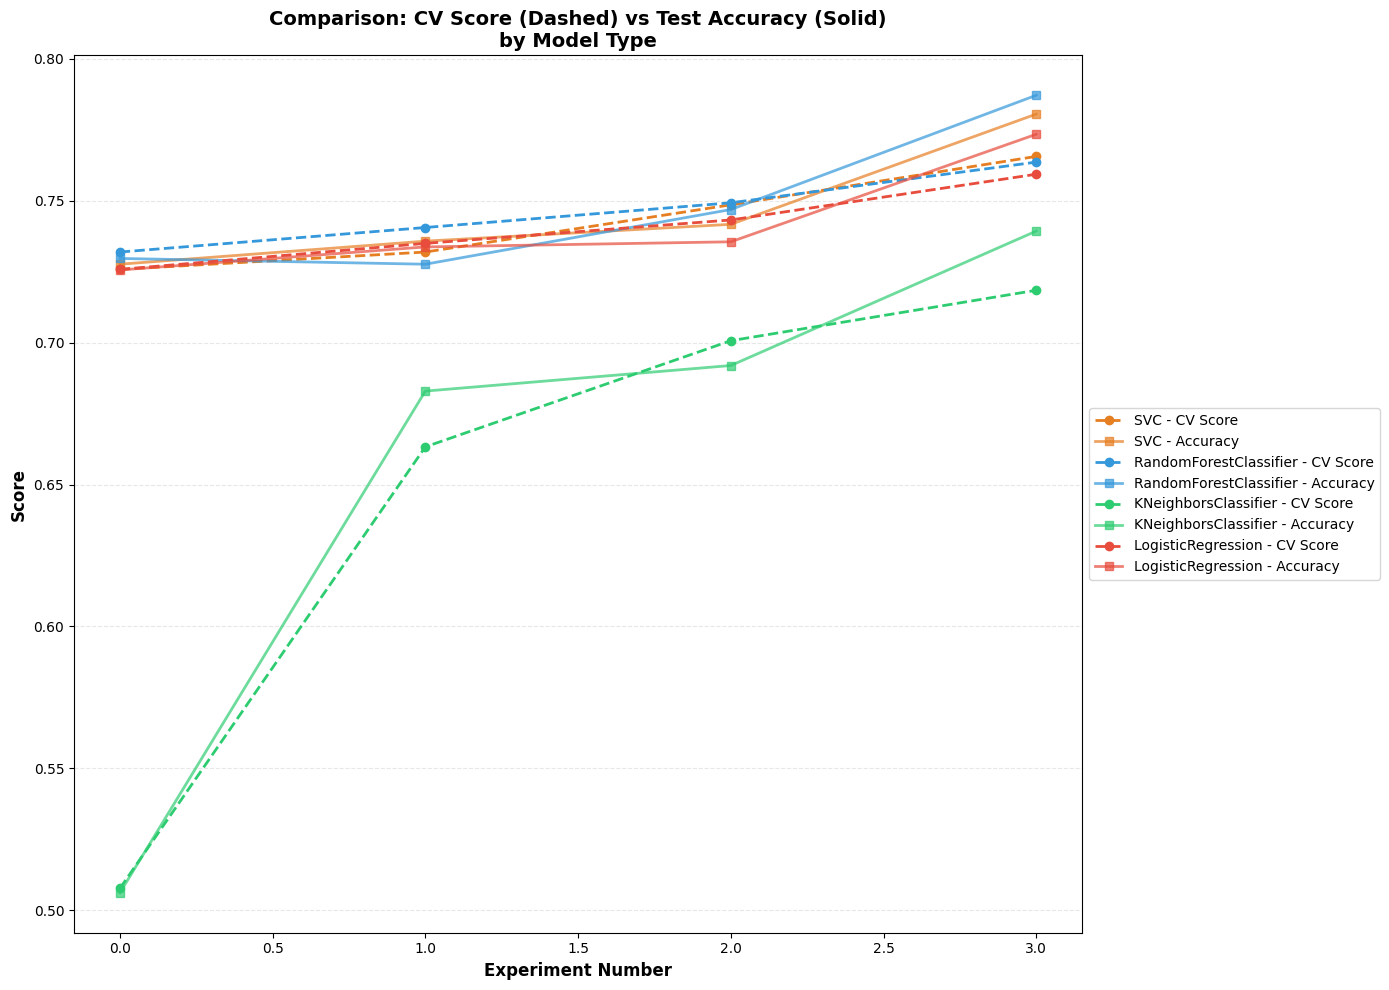

In [50]:
# 1. Load the history of results
df_stats = pd.read_csv(file_path)

# 2. Extract unique models for plotting
model_types = df_stats['model'].unique()
dfs_by_model = {m: df_stats[df_stats['model'] == m].reset_index(drop=True) for m in model_types}

# 3. Create the comparison plot
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#e67e22', '#3498db', '#2ecc71', '#e74c3c']

for idx, (name, data) in enumerate(dfs_by_model.items()):
    x = range(len(data))
    color = colors[idx % len(colors)]
    
    # Plot CV Score (dashed line)
    ax.plot(x, data['SCORE'], 'o--', color=color, linewidth=2, label=f"{name} - CV Score")
    
    # Plot Accuracy (solid line)
    ax.plot(x, data['ACCURACY'], 's-', color=color, linewidth=2, alpha=0.7, label=f"{name} - Accuracy")

# Plot styling
ax.set_xlabel('Experiment Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparison: CV Score (Dashed) vs Test Accuracy (Solid)\nby Model Type', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()